Use the Google stock prices dataset and design a time
series analysis and prediction system using RNN.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
def load_data(ticker='GOOG', start='2019-01-01', end='2024-01-01'):
    """
    Load historical stock prices from Yahoo Finance
    """
    data = yf.download(ticker, start=start, end=end)
    return data

In [15]:
def preprocess_data(data, feature_col='Close', window_size=60):
    """
    Preprocess data for RNN training:
    - Scale features
    - Create sequences of window_size time-steps as inputs and next step as output
    """
    dataset = data[[feature_col]].values
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)
    x, y = [], []
    for i in range(window_size, len(scaled_data)):
        x.append(scaled_data[i-window_size:i, 0])
        y.append(scaled_data[i, 0])
    x, y = np.array(x), np.array(y)
    x = np.reshape(x, (x.shape[0], x.shape[1], 1))  # reshape for RNN input
    return x, y, scaler

In [5]:
def build_rnn(input_shape):
    """
    Build a simple RNN model
    """
    model = Sequential()
    model.add(SimpleRNN(units=50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [6]:
def plot_predictions(actual, predicted):
    plt.figure(figsize=(12,6))
    plt.plot(actual, color='blue', label='Actual Prices')
    plt.plot(predicted, color='red', label='Predicted Prices')
    plt.title('Google Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()

In [7]:
def main():
    print("Loading Google stock price data...")
    data = load_data()
    print(f"Data loaded: {data.shape[0]} rows")

    window_size = 60
    print("Preprocessing data...")
    x, y, scaler = preprocess_data(data, window_size=window_size)
    print(f"Data prepared with window size = {window_size}")

    # Split into training and test sets (e.g. 80/20)
    train_size = int(len(x) * 0.8)
    x_train, y_train = x[:train_size], y[:train_size]
    x_test, y_test = x[train_size:], y[train_size:]

    print(f"Training samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")

    print("Building the RNN model...")
    model = build_rnn((window_size, 1))

    print("Training the model...")
    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

    print("Making predictions on test set...")
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)
    y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

    print("Plotting results...")
    plot_predictions(y_test_unscaled, predictions)

[*********************100%***********************]  1 of 1 completed

Loading Google stock price data...
Data loaded: 1258 rows
Preprocessing data...
Data prepared with window size = 60
Training samples: 958, Test samples: 240
Building the RNN model...
Training the model...
Epoch 1/100



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0275 - val_loss: 0.0044
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - val_loss: 0.0030
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.9476e-04 - val_loss: 0.0019
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.7543e-04 - val_loss: 0.0017
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.3787e-04 - val_loss: 0.0013
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.9374e-04 - val_loss: 0.0013
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.0433e-04 - val_loss: 0.0012
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 1

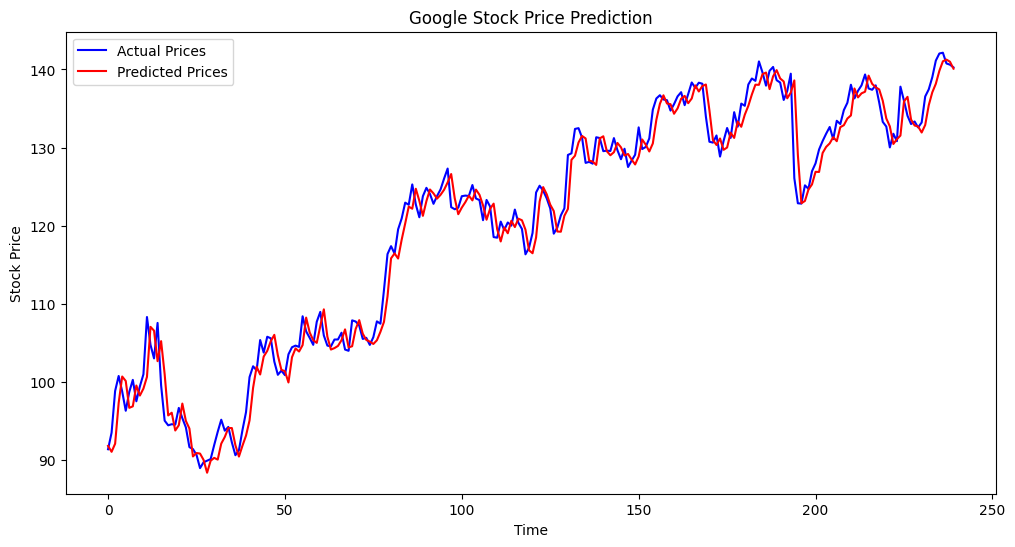

In [16]:
if __name__ == '__main__':
    main()